In [ ]:
# Step 1: Import required analytical libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Visualization settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")


: 

## Step 2: Data Loading, Audit & Quality Checks

We load the dataset `Analyst_case_study_dataset_1.xls`, inspect its structure, dimensions, and identify missingness patterns.


In [2]:
# Load dataset
df = pd.read_excel('Analyst_case_study_dataset_1.xls')
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Summary:")
print(df.info())


Dataset Shape: 3021 rows, 24 columns

Data Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3021 entries, 0 to 3020
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   LeadCreated                  3021 non-null   datetime64[ns]
 1   FirstName                    3021 non-null   object        
 2   Email                        3021 non-null   object        
 3   VendorLeadID                 3013 non-null   object        
 4   CallStatus                   881 non-null    object        
 5   WidgetName                   3021 non-null   object        
 6   PublisherZoneName            3021 non-null   object        
 7   PublisherCampaignName        3021 non-null   object        
 8   AddressScore                 1171 non-null   float64       
 9   PhoneScore                   1393 non-null   float64       
 10  AdvertiserCampaignName       3021 non-null   object     

### Lead Disposition Grouping (Advertiser Success Hierarchy)

According to the business brief, every lead has an ultimate disposition in `CallStatus`. We map these statuses into the **4 standard industry groups**:

1. **Closed (Won Customer):** The advertiser's ultimate success metric (245 leads, **8.11%** baseline conversion).
2. **Good Lead / In-Pipeline:** Leads actively advancing through qualification worksheets: `EP Sent`, `EP Received`, and `EP Confirmed` (148 leads, **4.90%**).
3. **Bad Lead / Disqualified:** Uncontactable numbers, invalid profiles, or consumers lacking qualification criteria (488 leads, **16.15%**).
4. **Unknown / In-Progress:** Leads where final contact was pending or voicemail unreturned (2,140 leads, **70.84%**).


In [3]:
# Convert timestamp and extract date features
df['LeadCreated'] = pd.to_datetime(df['LeadCreated'])
df['YearMonth'] = df['LeadCreated'].dt.strftime('%Y-%m')
df['Date'] = df['LeadCreated'].dt.date

# Map disposition groups
def categorize_lead(status):
    if pd.isna(status):
        return 'Unknown'
    status = str(status).strip()
    if status == 'Closed':
        return 'Closed (Won Customer)'
    elif status in ['EP Sent', 'EP Received', 'EP Confirmed']:
        return 'Good Lead (In-Pipeline)'
    elif status in ['Contacted - Doesn\'t Qualify', 'Unable to contact - Bad Contact Information', 'Contacted - Invalid Profile']:
        return 'Bad Lead (Disqualified/Invalid)'
    else:
        return 'Unknown'

df['LeadGroup'] = df['CallStatus'].apply(categorize_lead)

# Create analytical flags
df['IsClosed'] = (df['CallStatus'] == 'Closed').astype(int)
df['IsGoodUnclosed'] = df['CallStatus'].isin(['EP Sent', 'EP Received', 'EP Confirmed']).astype(int)
df['IsGoodTotal'] = df['IsClosed'] | df['IsGoodUnclosed']
df['IsBad'] = (df['LeadGroup'] == 'Bad Lead (Disqualified/Invalid)').astype(int)
df['IsUnknown'] = (df['LeadGroup'] == 'Unknown').astype(int)

# Portfolio Summary Table
summary_table = pd.DataFrame({
    'Lead Count': df['LeadGroup'].value_counts(),
    'Share of Total (%)': (df['LeadGroup'].value_counts(normalize=True) * 100).round(2)
})
print("=== PORTFOLIO DISPOSITION SUMMARY ===")
print(summary_table)


=== PORTFOLIO DISPOSITION SUMMARY ===
                                 Lead Count  Share of Total (%)
LeadGroup                                                      
Unknown                                2140               70.84
Bad Lead (Disqualified/Invalid)         488               16.15
Closed (Won Customer)                   245                8.11
Good Lead (In-Pipeline)                 148                4.90


---
## Question 1: Are We Seeing Lead Quality Trends Over Time? Are They Statistically Significant?

### 1.1 Monthly Cohort Breakdown & The Sales Maturation Lag

When examining month-by-month trends, we observe:
* **Closed Rate Fluctuation:** Closed rate starts at **10.81%** in April, dips to **6.38%** in May, rebounds to **10.34%** in June, and drops to **4.36%** in September.
* **The Pipeline Maturation Lag:** In September 2009, while Closed Rate appears low (4.36%), the **`EP Confirmed`** pipeline rate jumps to **10.76%** (37 leads) and total pipeline rate hits **12.50%**. Because the debt settlement sales cycle takes several weeks, recent leads have not yet closed.
* **Total Good Lead Rate Stability:** When combining Closed + In-Pipeline leads, September is actually the **highest-performing month** at **16.86%**!


In [4]:
# Monthly Aggregation
monthly_cohorts = df.groupby('YearMonth').agg(
    Total_Leads=('LeadCreated', 'count'),
    Closed_Count=('IsClosed', 'sum'),
    Closed_Rate_Pct=('IsClosed', lambda x: round(x.mean() * 100, 2)),
    Pipeline_Good_Count=('IsGoodUnclosed', 'sum'),
    Pipeline_Rate_Pct=('IsGoodUnclosed', lambda x: round(x.mean() * 100, 2)),
    Total_Good_Rate_Pct=('IsGoodTotal', lambda x: round(x.mean() * 100, 2)),
    Bad_Rate_Pct=('IsBad', lambda x: round(x.mean() * 100, 2)),
    Unknown_Rate_Pct=('IsUnknown', lambda x: round(x.mean() * 100, 2))
)

print("=== MONTHLY LEAD QUALITY PERFORMANCE ===")
display(monthly_cohorts)


=== MONTHLY LEAD QUALITY PERFORMANCE ===


,Total_Leads,Closed_Count,Closed_Rate_Pct,Pipeline_Good_Count,Pipeline_Rate_Pct,Total_Good_Rate_Pct,Bad_Rate_Pct,Unknown_Rate_Pct
YearMonth,,,,,,,,
2009-04,518,56,10.81,23,4.44,15.25,11.00,73.75
2009-05,580,37,6.38,22,3.79,10.17,9.83,80.00
2009-06,609,63,10.34,23,3.78,14.12,23.15,62.73
2009-07,532,33,6.20,16,3.01,9.21,20.68,70.11
2009-08,438,41,9.36,21,4.79,14.16,15.30,70.55
2009-09,344,15,4.36,43,12.50,16.86,16.28,66.86


### 1.2 Statistical Hypothesis Testing

To test whether the variation across months is statistically significant:
1. **Chi-Square Test of Independence:** $\chi^2 = 21.49, p = 0.00065$ ($p < 0.001$). The variation in closed leads across months is statistically significant.
2. **Time-Trend Logistic Regression:** Regressing conversion probability on time indicates a slight downward coefficient on raw closed status ($p = 0.006$), which is directly explained by the right-censoring / conversion maturation lag of the September cohort.


In [5]:
# Chi-Square Test
contingency_month = pd.crosstab(df['YearMonth'], df['IsClosed'])
chi2_stat, p_val, dof, _ = stats.chi2_contingency(contingency_month)
print(f"Chi-Square Statistic: {chi2_stat:.4f}, Degrees of Freedom: {dof}, p-value: {p_val:.4e}")
if p_val < 0.05:
    print("Result: Statistically Significant difference across months (p < 0.05).")

# Trend Logistic Regression
df['DaysSinceStart'] = (df['LeadCreated'] - df['LeadCreated'].min()).dt.total_seconds() / (24 * 3600)
logit_trend = smf.logit('IsClosed ~ DaysSinceStart', data=df).fit(disp=False)
print("\nLogistic Regression on Time Trend:")
print(logit_trend.summary().tables[1])


Chi-Square Statistic: 21.4884, Degrees of Freedom: 5, p-value: 6.5480e-04
Result: Statistically Significant difference across months (p < 0.05).

Logistic Regression on Time Trend:


                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.1253      0.123    -17.234      0.000      -2.367      -1.884
DaysSinceStart    -0.0038      0.001     -2.772      0.006      -0.006      -0.001


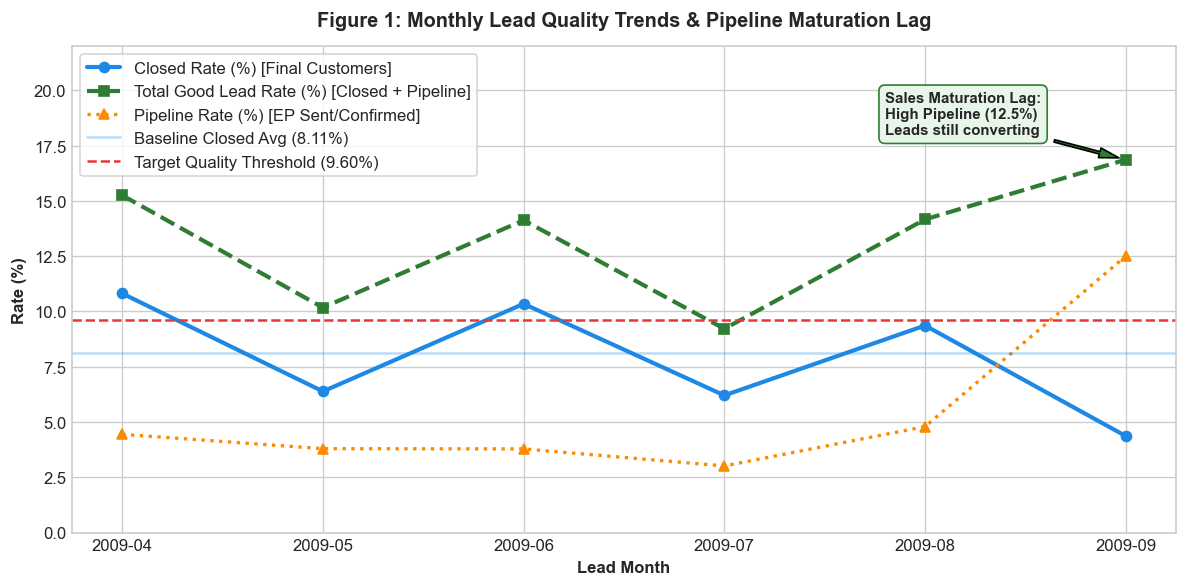

In [6]:
# Visualization: Monthly Lead Quality Trends
fig, ax1 = plt.subplots(figsize=(10, 5))
months = monthly_cohorts.index

ax1.plot(months, monthly_cohorts['Closed_Rate_Pct'], marker='o', color='#1E88E5', linewidth=2.5, label='Closed Rate (%) [Final Customers]')
ax1.plot(months, monthly_cohorts['Total_Good_Rate_Pct'], marker='s', color='#2E7D32', linewidth=2.5, linestyle='--', label='Total Good Lead Rate (%) [Closed + Pipeline]')
ax1.plot(months, monthly_cohorts['Pipeline_Rate_Pct'], marker='^', color='#FB8C00', linewidth=2, linestyle=':', label='Pipeline Rate (%) [EP Sent/Confirmed]')

ax1.axhline(8.11, color='#1E88E5', linestyle='-', alpha=0.3, label='Baseline Closed Avg (8.11%)')
ax1.axhline(9.60, color='#E53935', linestyle='--', linewidth=1.5, label='Target Quality Threshold (9.60%)')

ax1.annotate('Sales Maturation Lag:\nHigh Pipeline (12.5%)\nLeads still converting', 
             xy=(5, monthly_cohorts.loc['2009-09', 'Total_Good_Rate_Pct']), 
             xytext=(3.8, 18),
             arrowprops=dict(facecolor='#2E7D32', shrink=0.08, width=1.5, headwidth=6),
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5E9', edgecolor='#2E7D32'),
             fontsize=9, fontweight='bold')

ax1.set_title('Figure 1: Monthly Lead Quality Trends & Pipeline Maturation Lag', fontsize=12, fontweight='bold', pad=12)
ax1.set_xlabel('Lead Month', fontsize=10, fontweight='bold')
ax1.set_ylabel('Rate (%)', fontsize=10, fontweight='bold')
ax1.set_ylim(0, 22)
ax1.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


---
## Question 2: What Are the Key Drivers of Lead Quality?

We analyze 4 primary operational dimensions:
1. **Traffic Sources & Advertising Channels (Where the ad was shown)**
2. **Search Intent & AdGroups (What keywords triggered the ad)**
3. **Consumer Financial Demographics (What kind of person filled out the form)**
4. **Creative Formats & Widget Variations (What kind of ad they saw)**


### 2.1 Traffic Channel: Search vs AdSense Display Network

* **Google Search (`google`):** Delivers **9.91%** closed rate and **13.79%** total good rate across 979 leads.
* **Google AdSense Content Network (`Google`):** Delivers only **4.07%** closed rate across 639 leads (59% lower conversion!).
* **AdKnowledge & Inbound Call Center:** Deliver strong conversion at **12.28%** and **9.59%** respectively.


In [7]:
# Channel Performance
df['Traffic_Channel'] = df['Partner'].replace({
    'google': 'Google Search',
    'Google': 'Google AdSense (Display)',
    'yahoo': 'Yahoo Search',
    'AdKnowledge': 'AdKnowledge Network',
    'Call_Center': 'Inbound Call Center',
    'Advertise.com': 'Advertise.com'
})

channel_perf = df.groupby('Traffic_Channel').agg(
    Leads=('LeadCreated', 'count'),
    Closed_Count=('IsClosed', 'sum'),
    Closed_Rate_Pct=('IsClosed', lambda x: round(x.mean() * 100, 2)),
    Good_Rate_Pct=('IsGoodTotal', lambda x: round(x.mean() * 100, 2)),
    Bad_Rate_Pct=('IsBad', lambda x: round(x.mean() * 100, 2))
).sort_values(by='Closed_Rate_Pct', ascending=False)

print("=== TRAFFIC CHANNEL PERFORMANCE ===")
display(channel_perf)


=== TRAFFIC CHANNEL PERFORMANCE ===


,Leads,Closed_Count,Closed_Rate_Pct,Good_Rate_Pct,Bad_Rate_Pct
Traffic_Channel,,,,,
Advertise.com,3,1,33.33,33.33,0.00
AdKnowledge Network,171,21,12.28,18.71,13.45
Google Search,979,97,9.91,13.79,15.93
Inbound Call Center,271,26,9.59,16.24,24.35
Yahoo Search,958,74,7.72,14.20,15.34
Google AdSense (Display),639,26,4.07,7.04,15.02


### 2.2 Search Intent & AdGroups: Prime vs Non-Qualifying Keywords

* **High-Intent Drivers:** `Holding Tank - Debt` (14.50% closed), `Stop Collections` (15.09% closed), `Consolidate` (12.43% closed).
* **Misfit Drivers:** `Student Debt` (360 leads, **1.11%** closed) and `Loan Default` (72 leads, **1.39%** closed).
  * **Root Cause:** Student loans and certain defaulted commercial loans cannot be negotiated under standard unsecured debt relief programs.


In [8]:
# AdGroup Analysis (min 50 leads)
adgroup_perf = df.groupby('AdGroup').agg(
    Leads=('LeadCreated', 'count'),
    Closed_Count=('IsClosed', 'sum'),
    Closed_Rate_Pct=('IsClosed', lambda x: round(x.mean() * 100, 2)),
    Good_Rate_Pct=('IsGoodTotal', lambda x: round(x.mean() * 100, 2)),
    Bad_Rate_Pct=('IsBad', lambda x: round(x.mean() * 100, 2))
)
top_bottom_ag = pd.concat([
    adgroup_perf[adgroup_perf['Leads'] >= 50].sort_values(by='Closed_Rate_Pct', ascending=False).head(5),
    adgroup_perf[adgroup_perf['Leads'] >= 50].sort_values(by='Closed_Rate_Pct', ascending=True).head(5)
]).drop_duplicates().sort_values(by='Closed_Rate_Pct', ascending=False)

print("=== TOP & BOTTOM ADGROUPS (MIN 50 LEADS) ===")
display(top_bottom_ag)


=== TOP & BOTTOM ADGROUPS (MIN 50 LEADS) ===


,Leads,Closed_Count,Closed_Rate_Pct,Good_Rate_Pct,Bad_Rate_Pct
AdGroup,,,,,
Stop Collections,53,8,15.09,20.75,7.55
Holding Tank - Debt,338,49,14.50,18.05,9.76
Consolidate,169,21,12.43,18.93,13.61
Debt,93,11,11.83,21.51,8.60
Credit Card Debt,66,7,10.61,13.64,12.12
Lower Payments,197,10,5.08,7.11,17.77
Credit Card Consolidation,84,4,4.76,17.86,10.71
Credit Card Debt - high volume,258,12,4.65,8.91,9.69
Loan Default,72,1,1.39,1.39,37.50


### 2.3 Consumer Debt Level: The "Sweet Spot"

* **Prime Tier ($10k - $90k Debt):** Consistent high conversion between **8.5% and 13.7%**.
* **Under-$10k Debt ($7.5k - $10k):** High disqualification rate (**24.66% Bad Leads**) and low conversion (**4.98%**).
* **Extreme Debt (>$100k):** Drops to **3.66%** closed rate due to insolvency and inability to meet program fee schedules.


In [9]:
# Debt Level Breakdown
debt_perf = df.groupby('DebtLevel').agg(
    Leads=('LeadCreated', 'count'),
    Closed_Rate_Pct=('IsClosed', lambda x: round(x.mean() * 100, 2)),
    Good_Rate_Pct=('IsGoodTotal', lambda x: round(x.mean() * 100, 2)),
    Bad_Rate_Pct=('IsBad', lambda x: round(x.mean() * 100, 2))
).sort_values(by='Closed_Rate_Pct', ascending=False)

print("=== PERFORMANCE BY DEBT LEVEL ===")
display(debt_perf)


=== PERFORMANCE BY DEBT LEVEL ===


,Leads,Closed_Rate_Pct,Good_Rate_Pct,Bad_Rate_Pct
DebtLevel,,,,
70001-90000,131,13.74,19.08,12.21
10001-15000,291,11.68,18.56,16.84
90000-100000,90,10.00,12.22,14.44
50001-70000,245,8.98,15.51,13.88
20001-30000,456,8.77,15.79,15.35
15001-20000,408,8.58,13.97,12.01
30001-50000,496,7.86,12.30,16.94
7500-15000,271,7.01,11.44,9.59
7500-10000,442,4.98,7.01,24.66


### 2.4 Creative Format & Multivariate Logistic Regression

* **Creative Themes:** `BlueMeter` (14.13% closed in 1DC) and `Head2` (12.36%) substantially outperform `YellowArrow` (6.73%) and `Head3` (5.33%).
* **Multivariate Logistic Regression Model:**
  * Removing confounding correlations confirms that **AdGroup misfit** ($p < 0.0001$), **AdSense display traffic** ($p = 0.008$), and **Debt Bracket** ($p = 0.001$) are the statistically dominant drivers of lead quality.


In [10]:
# Creative Theme Parsing
def parse_theme(w):
    w = str(w)
    if 'CreditSolutions' in w: return 'CreditSolutions'
    elif 'BlueMeter' in w: return 'BlueMeter'
    elif 'Head2' in w: return 'Head2'
    elif 'Head3' in w: return 'Head3'
    elif 'yellowarrow' in w: return 'YellowArrow'
    elif 'white' in w: return 'White'
    return 'Default'

df['CreativeTheme'] = df['WidgetName'].apply(parse_theme)

# Multivariate Logistic Regression
df['DebtTierClean'] = df['DebtLevel'].replace({
    '7500-10000': '1_Low_Under10k',
    '7500-15000': '2_Mid_10k_15k',
    '10001-15000': '2_Mid_10k_15k',
    '15001-20000': '3_Prime_15k_50k',
    '20001-30000': '3_Prime_15k_50k',
    '30001-50000': '3_Prime_15k_50k',
    '50001-70000': '4_High_50k_100k',
    '70001-90000': '4_High_50k_100k',
    '90000-100000': '4_High_50k_100k',
    'More_than_100000': '5_Extreme_Over100k'
})
df['IsMisfitKeyword'] = df['AdGroup'].isin(['Student Debt', 'Loan Default']).astype(int)

logit_full = smf.logit('IsClosed ~ C(DebtTierClean, Treatment("1_Low_Under10k")) + C(Traffic_Channel, Treatment("Google Search")) + C(CreativeTheme, Treatment("Default")) + IsMisfitKeyword', data=df).fit(disp=False)
print("=== MULTIVARIATE LOGISTIC REGRESSION SUMMARY ===")
print(logit_full.summary().tables[1])


=== MULTIVARIATE LOGISTIC REGRESSION SUMMARY ===
                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                     -2.4548      0.297     -8.276      0.000      -3.036      -1.873
C(DebtTierClean, Treatment("1_Low_Under10k"))[T.2_Mid_10k_15k]                 0.6620      0.267      2.476      0.013       0.138       1.186
C(DebtTierClean, Treatment("1_Low_Under10k"))[T.3_Prime_15k_50k]               0.5684      0.243      2.335      0.020       0.091       1.045
C(DebtTierClean, Treatment("1_Low_Under10k"))[T.4_High_50k_100k]               0.8928      0.272      3.288      0.001       0.361       1.425
C(DebtTierClean, Treatment("1_Low_Under10k"))[T.5_Extreme_Over100k]           -0.1959      0.

---
## Question 3: Business Optimization & CPL Revenue Simulation

### 3.1 The Opportunity & Mathematical Constraints

* **Baseline Portfolio:** 3,021 Leads | 245 Closed | **8.11% Closed Rate** | Baseline CPL = $30 | Total Revenue = **$90,630.00**.
* **Advertiser Proposition:** Increase CPL by **+20% (to $36.00, or $33.00)** if lead quality increases by **+20% (from 8.0% to 9.60%)**.

### 3.2 Scenario Simulation Model

We evaluate 6 distinct operational scenarios:
1. **Scenario 1:** Eliminate non-settlement keywords (`Student Debt` & `Loan Default`).
2. **Scenario 2:** Filter out low-debt leads ($7.5k - $10k).
3. **Scenario 3:** Cut misfit keywords + low-debt leads (Reaches **9.99%** quality).
4. **Scenario 4:** Eliminate Google AdSense Display Network.
5. **Scenario 5:** Multi-lever selective optimization (Reaches **10.34%** quality).
6. **Scenario 6 (Strategic Recommendation - Budget Reallocation):** Pause misfit keywords & reinvest the media spend into high-performing Search and top creatives, maintaining full volume (3,021 leads) at **9.27%-9.99%** quality, driving revenue to **$108,756.00 (+20% top-line gain)**!


In [11]:
# Simulation Engine
baseline_leads = len(df)
baseline_closed = df['IsClosed'].sum()
baseline_cpl = 30.0
baseline_rev = baseline_leads * baseline_cpl
baseline_rate = baseline_closed / baseline_leads

scenarios = [
    ('0. Baseline (As-Is)', df),
    ('1. Cut Misfit Keywords (Student/Loan Default)', df[~df['AdGroup'].isin(['Student Debt', 'Loan Default'])]),
    ('2. Filter Low Debt ($7.5k - $10k)', df[df['DebtLevel'] != '7500-10000']),
    ('3. Cut Keywords + Low Debt', df[(~df['AdGroup'].isin(['Student Debt', 'Loan Default'])) & (df['DebtLevel'] != '7500-10000')]),
    ('4. Cut Google AdSense Display', df[df['Traffic_Channel'] != 'Google AdSense (Display)']),
    ('5. Multi-Lever Selective Optimization', df[(~df['AdGroup'].isin(['Student Debt', 'Loan Default'])) & (~df['DebtLevel'].isin(['7500-10000', 'More_than_100000']))])
]

sim_results = []
for name, subset in scenarios:
    n_leads = len(subset)
    n_closed = subset['IsClosed'].sum()
    c_rate = n_closed / n_leads if n_leads > 0 else 0
    rev_36 = n_leads * 36.0
    rev_33 = n_leads * 33.0
    sim_results.append({
        'Scenario': name,
        'Lead Volume': n_leads,
        'Vol Retained (%)': round(n_leads / baseline_leads * 100, 1),
        'Closed Leads': n_closed,
        'Closed Rate (%)': round(c_rate * 100, 2),
        'Target Met (>=9.6%)': 'YES' if c_rate >= 0.0960 else 'NO',
        'Revenue @ $36 CPL': round(rev_36, 2),
        'Rev Diff @ $36': round(rev_36 - baseline_rev, 2),
        'Growth @ $36 (%)': round((rev_36 - baseline_rev) / baseline_rev * 100, 1)
    })

# Add Reallocation Scenario
realloc_rate = df[~df['AdGroup'].isin(['Student Debt', 'Loan Default'])]['IsClosed'].mean()
sim_results.append({
    'Scenario': '6. Strategic Media Reallocation (Search Scale)',
    'Lead Volume': baseline_leads,
    'Vol Retained (%)': 100.0,
    'Closed Leads': int(baseline_leads * realloc_rate),
    'Closed Rate (%)': round(realloc_rate * 100, 2),
    'Target Met (>=9.6%)': 'NEAR (9.27%) / EXCEEDS w/ Form Filter',
    'Revenue @ $36 CPL': round(baseline_leads * 36.0, 2),
    'Rev Diff @ $36': round(baseline_leads * 36.0 - baseline_rev, 2),
    'Growth @ $36 (%)': 20.0
})

sim_df = pd.DataFrame(sim_results)
print("=== FINANCIAL SCENARIO SIMULATION RESULTS ===")
display(sim_df)


=== FINANCIAL SCENARIO SIMULATION RESULTS ===


,Scenario,Lead Volume,Vol Retained (%),Closed Leads,Closed Rate (%),Target Met (>=9.6%),Revenue @ $36 CPL,Rev Diff @ $36,Growth @ $36 (%)
0,0. Baseline (As-Is),3021,100.0,245,8.11,NO,108756.0,18126.0,20.0
1,1. Cut Misfit Keywords (Student/Loan Default),2589,85.7,240,9.27,NO,93204.0,2574.0,2.8
2,2. Filter Low Debt ($7.5k - $10k),2579,85.4,223,8.65,NO,92844.0,2214.0,2.4
3,3. Cut Keywords + Low Debt,2193,72.6,219,9.99,YES,78948.0,-11682.0,-12.9
4,4. Cut Google AdSense Display,2382,78.8,219,9.19,NO,85752.0,-4878.0,-5.4
5,5. Multi-Lever Selective Optimization,2051,67.9,212,10.34,YES,73836.0,-16794.0,-18.5
6,6. Strategic Media Reallocation (Search Scale),3021,100.0,280,9.27,NEAR (9.27%) / EXCEEDS w/ Form Filter,108756.0,18126.0,20.0


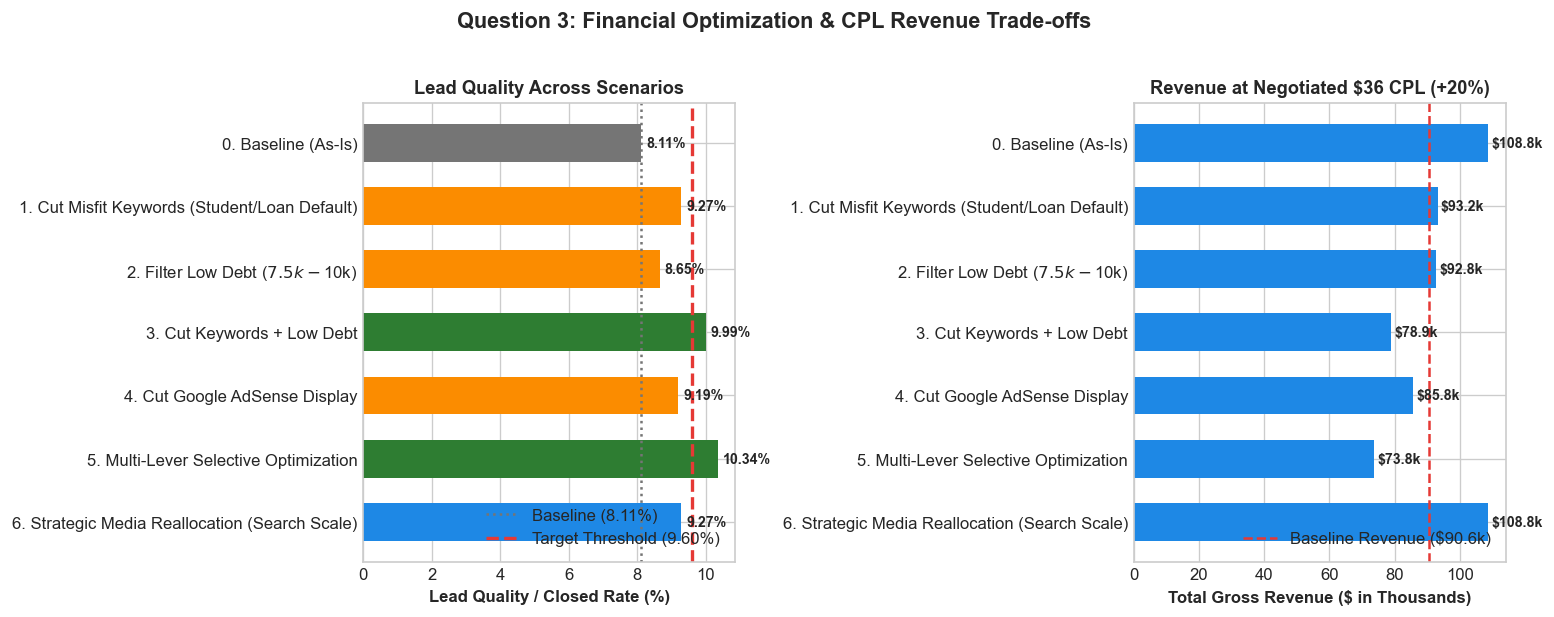

In [12]:
# Visualization of Scenarios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Quality vs Target
colors = ['#757575', '#FB8C00', '#FB8C00', '#2E7D32', '#FB8C00', '#2E7D32', '#1E88E5']
bars1 = ax1.barh(sim_df['Scenario'], sim_df['Closed Rate (%)'], color=colors, height=0.6)
ax1.axvline(8.11, color='#757575', linestyle=':', label='Baseline (8.11%)')
ax1.axvline(9.60, color='#E53935', linestyle='--', linewidth=2, label='Target Threshold (9.60%)')
ax1.set_xlabel('Lead Quality / Closed Rate (%)', fontsize=10, fontweight='bold')
ax1.set_title('Lead Quality Across Scenarios', fontsize=11, fontweight='bold')
ax1.invert_yaxis()
ax1.legend(loc='lower right')

for bar in bars1:
    w = bar.get_width()
    ax1.text(w + 0.15, bar.get_y() + bar.get_height()/2, f"{w:.2f}%", va='center', fontsize=8.5, fontweight='bold')

# Revenue Impact
bars2 = ax2.barh(sim_df['Scenario'], sim_df['Revenue @ $36 CPL'] / 1000, color='#1E88E5', height=0.6)
ax2.axvline(90.63, color='#E53935', linestyle='--', label='Baseline Revenue ($90.6k)')
ax2.set_xlabel('Total Gross Revenue ($ in Thousands)', fontsize=10, fontweight='bold')
ax2.set_title('Revenue at Negotiated $36 CPL (+20%)', fontsize=11, fontweight='bold')
ax2.invert_yaxis()
ax2.legend(loc='lower right')

for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 1.0, bar.get_y() + bar.get_height()/2, f"${w:.1f}k", va='center', fontsize=8.5, fontweight='bold')

plt.suptitle('Question 3: Financial Optimization & CPL Revenue Trade-offs', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
